In [2]:
import pandas as pd
import numpy as np
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top30_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv"
OUTPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/final_gene_to_mz_top30_matches_all_scores.csv'

# RRF Constant (k): 
# k=0 makes Rank 1 much more valuable than Rank 2 (aggressive).
# k=60 makes Rank 1 and Rank 10 closer in value (smoother).
# For Top 10 lists, k=1 is usually a good balance.
K_FACTOR = 1
GROUPS = ['AAD', 'YC', 'AC', 'YAD'] 
TOLERANCE = 0.015  

DIFFS = {
    'Isotope (M+1)': 1.003355,   
    'Isotope (M+2)': 2.006710,   
    'Adduct (NH4)':  17.02655,   
    'Adduct (Na)':   21.98204,   
    'Adduct (K)':    37.95548,   
    'Loss (H2O)':    -18.01056   
}

# =============================================================================
# LOAD VALIDATION DATA (CHECKPOINT PREP)
# =============================================================================
def load_validation_lookup(path):
    try:
        val_df = pd.read_csv(path)
        # Create a set of frozen sets for order-independent lookup: {frozenset({mz1, mz2}), ...}
        # Rounding to 4 decimals to handle float precision differences
        lookup = set()
        for _, row in val_df.iterrows():
            pair = frozenset([round(row['mz_1'], 4), round(row['mz_2'], 4)])
            lookup.add(pair)
        print(f"Loaded {len(lookup)} validated isotope pairs.")
        return lookup
    except Exception as e:
        print(f"Error loading validation file: {e}")
        return set()

VALID_ISOTOPE_PAIRS = load_validation_lookup(VALIDATION_FILE)

# =============================================================================
# HELPER: CHECK RELATIONSHIPS
# =============================================================================
def get_relationship(parent_mz, child_mz):
    diff = child_mz - parent_mz
    potential_rel = None
    
    # 1. Determine Mathematical Relationship
    if abs(diff - DIFFS['Isotope (M+1)']) < TOLERANCE: potential_rel = "M+1"
    elif abs(diff - DIFFS['Isotope (M+2)']) < TOLERANCE: potential_rel = "M+2"
    elif abs(diff - DIFFS['Adduct (NH4)']) < TOLERANCE: potential_rel = "NH4"
    elif abs(diff - DIFFS['Adduct (Na)']) < TOLERANCE: potential_rel = "Na"
    elif abs(diff - DIFFS['Adduct (K)']) < TOLERANCE: potential_rel = "K"
    elif abs(diff - DIFFS['Loss (H2O)']) < TOLERANCE: potential_rel = "H2O Loss"
    
    # Sodium vs Ammonium check
    na_nh4_diff = DIFFS['Adduct (Na)'] - DIFFS['Adduct (NH4)']
    if potential_rel is None and abs(diff - na_nh4_diff) < TOLERANCE: 
        potential_rel = "Na (vs NH4)"
    
    # 2. CHECKPOINT: Only allow Isotope relationships if they exist in the validation file
    if potential_rel in ["M+1", "M+2"]:
        pair = frozenset([round(parent_mz, 4), round(child_mz, 4)])
        if pair not in VALID_ISOTOPE_PAIRS:
            return None # Reject mathematical match because it's not validated
            
    return potential_rel

def identify_group(sample_name):
    for g in GROUPS:
        if g in sample_name:
            return g
    return "Other"

# =============================================================================
# CONSENSUS ALGORITHM
# =============================================================================
def calculate_consensus(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return None
    
    # Calculate Total Samples per Group (for denominator)
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    
    total_counts_per_group = {g: 0 for g in GROUPS + ['Other']}
    for s in all_samples:
        total_counts_per_group[identify_group(s)] += 1
    
    # 1. First Pass: Gather raw data per m/z
    mz_data = {} 
    for _, row in subset.iterrows():
        mz = row['MZ_Feature']
        sample = row['Sample']
        rank = row['Rank']
        group = identify_group(sample)
        
        if mz not in mz_data:
            mz_data[mz] = {
                'samples': set(), 
                'group_samples': {g: set() for g in GROUPS + ['Other']},
                'rrf': 0.0
            }
        mz_data[mz]['samples'].add(sample)
        mz_data[mz]['group_samples'][group].add(sample)
        mz_data[mz]['rrf'] += 1.0 / (rank + K_FACTOR)

    if not mz_data: return None

    # 2. Second Pass: Unify Counts (Parent absorbs Children)
    candidates = list(mz_data.keys())
    final_stats = []
    
    for parent in candidates:
        # Clone sets
        consolidated_all = mz_data[parent]['samples'].copy()
        consolidated_groups = {g: mz_data[parent]['group_samples'][g].copy() for g in GROUPS + ['Other']}
        children_found = []
        
        for child in candidates:
            if parent == child: continue
            rel = get_relationship(parent, child)
            if rel:
                # Merge ALL samples
                consolidated_all.update(mz_data[child]['samples'])

                # Merge GROUP samples
                for g in GROUPS + ['Other']:
                    consolidated_groups[g].update(mz_data[child]['group_samples'][g])
                children_found.append(f"{rel}")

        children_found = list(set(children_found))

        # Build Group Strings (e.g., "AAD:3/4")
        group_str_parts = []
        group_counts_numeric = {}
        for g in GROUPS:
            found = len(consolidated_groups[g])
            total = total_counts_per_group[g]
            group_str_parts.append(f"{g}:{found}/{total}")
            group_counts_numeric[g] = found

        final_stats.append({
            'mz': parent,
            'rrf': mz_data[parent]['rrf'],
            'total_count': len(consolidated_all),
            'group_counts': group_counts_numeric,
            'group_display': " | ".join(group_str_parts),
            'children': ", ".join(children_found)
        })

    # 3. Sort
    final_stats.sort(key=lambda x: x['rrf'], reverse=True)
    winner = final_stats[0]
    
    # Check if winner is potentially an artifact itself
    chem_flag = "Primary"
    for other in candidates:
        if other == winner['mz']: continue
        rel = get_relationship(other, winner['mz'])
        if rel:
            chem_flag = f"{rel} of {other:.4f}"
            break

    return {
        'winner': winner['mz'],
        'data': winner,
        'chem_flag': chem_flag,
        'total_samples_overall': total_samples_overall
    }

# =============================================================================
# MAIN EXECUTION
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"Error: Could not find '{INPUT_FILE}'.")
    exit()

unique_genes = df['Gene'].unique()
print(f"\n{'GENE':<15} | {'WINNER':<10} | {'TOTAL':<8} | {'CONF':<8} | {'GROUP BREAKDOWN':<45} | {'NOTES'}")
print("-" * 150)

results = []
for gene in unique_genes:
    res = calculate_consensus(df, gene)
    if not res: continue
    
    w = res['data']
    total_found = w['total_count']
    total_possible = res['total_samples_overall']
    
    # Calculate Confidence
    pct = (total_found / total_possible) * 100
    confidence = "LOW"
    if pct >= 50: confidence = "MEDIUM"
    if pct >= 75: confidence = "HIGH"
    if pct >= 90: confidence = "V.HIGH"
    
    total_str = f"{total_found}/{total_possible}"

    # Notes
    notes = []
    if res['chem_flag'] != "Primary": notes.append(f"⚠️ {res['chem_flag']}")
    if w['children']: notes.append(f"Incl: {w['children']}")

    print(f"{gene:<15} | {res['winner']:<10.4f} | {total_str:<8} | {confidence:<8} | {w['group_display']:<45} | {'; '.join(notes)}")
    
    # Save Dict
    row_data = {
        'Gene': gene,
        'Consensus_MZ': res['winner'],
        'Total_Found': total_found,
        'Total_Possible': total_possible,
        'Confidence': confidence,
        'Isotope_Flag': res['chem_flag'],
        'Merged_Isotopes': w['children']
    }
    # Add dynamic group columns
    for g in GROUPS:
        row_data[f'Count_{g}'] = w['group_counts'][g]
    results.append(row_data)

# Save
pd.DataFrame(results).to_csv(OUTPUT_FILE, index=False)
print("-" * 150)
print(f"Complete. Results saved to {OUTPUT_FILE}")

Loaded 531 validated isotope pairs.

GENE            | WINNER     | TOTAL    | CONF     | GROUP BREAKDOWN                               | NOTES
------------------------------------------------------------------------------------------------------------------------------------------------------
AC149090.1      | 821.5308   | 9/16     | MEDIUM   | AAD:0/4 | YC:3/4 | AC:3/4 | YAD:3/4           | ⚠️ M+1 of 820.5250
Aplp1           | 628.5358   | 6/16     | LOW      | AAD:2/4 | YC:0/4 | AC:1/4 | YAD:3/4           | ⚠️ M+1 of 627.5340; Incl: M+1
Apoe            | 780.5501   | 6/16     | LOW      | AAD:0/4 | YC:4/4 | AC:1/4 | YAD:1/4           | ⚠️ Na of 758.5688; Incl: M+1
App             | 755.5406   | 10/16    | MEDIUM   | AAD:3/4 | YC:4/4 | AC:2/4 | YAD:1/4           | ⚠️ M+1 of 754.5364; Incl: M+2, M+1
Atp1a3          | 878.5697   | 9/16     | MEDIUM   | AAD:3/4 | YC:1/4 | AC:1/4 | YAD:4/4           | ⚠️ Na of 856.5819
Elavl3          | 858.6960   | 10/16    | MEDIUM   | AAD:4/4 | YC:0/4

In [1]:
import pandas as pd
import numpy as np
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top30_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv"
OUTPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/final_gene_to_mz_top30_matches_all_scores.csv'

# RRF and Synergy Constants
K_FACTOR = 1
SYNERGY_WEIGHT = 0.5  # Bonus for each sample where two related peaks appear together
TOLERANCE = 0.015  
GROUPS = ['AAD', 'YC', 'AC', 'YAD'] 

# Theoretical Mass shifts relative to the Neutral Parent (M)
RELATIONSHIPS = {
    'M+0': 0.0,
    'M+1': 1.003355,
    'M+2': 2.006710,
    'NH4': 17.02655,
    'Na':  21.98204,
    'K':   37.95548,
    'H2O': -18.01056
}

# =============================================================================
# DATA LOADING & VALIDATION LOOKUP
# =============================================================================
def load_validation_lookup(path):
    """
    Loads the PhD Thesis validation file. If two m/zs appear in the same row,
    they are considered a validated pair.
    """
    try:
        val_df = pd.read_csv(path)
        lookup = set()
        for _, row in val_df.iterrows():
            # Using frozenset so order (mz_1 vs mz_2) doesn't matter
            pair = frozenset([round(row['mz_1'], 4), round(row['mz_2'], 4)])
            lookup.add(pair)
        print(f"Successfully loaded {len(lookup)} validated pairs from {path}")
        return lookup
    except Exception as e:
        print(f"Error loading validation file: {e}")
        return set()

VALID_PAIRS = load_validation_lookup(VALIDATION_FILE)

# =============================================================================
# RELATIONSHIP ENGINE
# =============================================================================
def check_relationship(mz1, mz2):
    """
    Determines if two m/z values are related either by:
    1. Direct presence in the Validation CSV.
    2. Mathematical sibling relationship (sharing a theoretical parent).
    """
    m1_r = round(mz1, 4)
    m2_r = round(mz2, 4)
    current_pair = frozenset([m1_r, m2_r])

    # RULE 1: Validation File is the "Gold Standard"
    if current_pair in VALID_PAIRS:
        return "Validated_Relationship"

    # RULE 2: Mathematical Sibling Check
    # This handles M+1 and Adduct appearing without the parent.
    diff = abs(mz2 - mz1)
    for name1, shift1 in RELATIONSHIPS.items():
        for name2, shift2 in RELATIONSHIPS.items():
            if name1 == name2: continue
            
            theoretical_diff = abs(shift2 - shift1)
            if abs(diff - theoretical_diff) < TOLERANCE:
                # Based on your requirement: Isotope matches MUST be validated.
                # If the math suggests an isotope relationship but it wasn't in 
                # the CSV, we reject it.
                is_isotope_rel = any(x in [name1, name2] for x in ['M+1', 'M+2'])
                if is_isotope_rel:
                    return None 
                
                return f"Math_{name1}<->{name2}"
    
    return None

def identify_group(sample_name):
    for g in GROUPS:
        if g in sample_name: return g
    return "Other"

# =============================================================================
# CONSENSUS ALGORITHM
# =============================================================================
def calculate_consensus(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return None
    
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    total_counts_per_group = {g: 0 for g in GROUPS + ['Other']}
    for s in all_samples:
        total_counts_per_group[identify_group(s)] += 1
    
    # 1. Map samples and base scores to each MZ
    mz_data = {} 
    for _, row in subset.iterrows():
        mz = row['MZ_Feature']
        if mz not in mz_data:
            mz_data[mz] = {
                'samples': set(), 
                'group_samples': {g: set() for g in GROUPS + ['Other']},
                'rrf_score': 0.0
            }
        group = identify_group(row['Sample'])
        mz_data[mz]['samples'].add(row['Sample'])
        mz_data[mz]['group_samples'][group].add(row['Sample'])
        mz_data[mz]['rrf_score'] += 1.0 / (row['Rank'] + K_FACTOR)

    candidates = list(mz_data.keys())
    final_stats = []
    
    # 2. Family Analysis: Every MZ looks for its siblings/children
    for focal_mz in candidates:
        consolidated_all = mz_data[focal_mz]['samples'].copy()
        consolidated_groups = {g: mz_data[focal_mz]['group_samples'][g].copy() for g in GROUPS + ['Other']}
        boosted_score = mz_data[focal_mz]['rrf_score']
        related_found = []
        
        for other_mz in candidates:
            if focal_mz == other_mz: continue
            
            rel_type = check_relationship(focal_mz, other_mz)
            if rel_type:
                # Merge observation data
                consolidated_all.update(mz_data[other_mz]['samples'])
                for g in GROUPS + ['Other']:
                    consolidated_groups[g].update(mz_data[other_mz]['group_samples'][g])
                
                # Apply SYNERGY BONUS: 
                # If both peaks appear in the same sample top 30, it's strong evidence.
                co_occurrence = mz_data[focal_mz]['samples'].intersection(mz_data[other_mz]['samples'])
                boosted_score += mz_data[other_mz]['rrf_score'] + (len(co_occurrence) * SYNERGY_WEIGHT)
                related_found.append(rel_type)

        group_counts = {g: len(consolidated_groups[g]) for g in GROUPS}
        group_display = " | ".join([f"{g}:{group_counts[g]}/{total_counts_per_group[g]}" for g in GROUPS])

        final_stats.append({
            'mz': focal_mz,
            'final_score': boosted_score,
            'total_count': len(consolidated_all),
            'group_counts': group_counts,
            'group_display': group_display,
            'notes': ", ".join(list(set(related_found)))
        })

    # 3. Rank families by their synergy-boosted scores
    final_stats.sort(key=lambda x: x['final_score'], reverse=True)
    winner = final_stats[0]
    
    return {
        'winner': winner['mz'],
        'data': winner,
        'total_samples_overall': total_samples_overall
    }

# =============================================================================
# MAIN EXECUTION
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"Error: Could not find '{INPUT_FILE}'.")
    exit()

unique_genes = df['Gene'].unique()
results = []

print(f"\n{'GENE':<15} | {'WINNER':<10} | {'SAMPLES':<8} | {'SCORE':<8} | {'NOTES'}")
print("-" * 120)

for gene in unique_genes:
    res = calculate_consensus(df, gene)
    if not res: continue
    
    w = res['data']
    pct = (w['total_count'] / res['total_samples_overall']) * 100
    confidence = "LOW"
    if pct >= 50: confidence = "MEDIUM"
    if pct >= 75: confidence = "HIGH"
    if pct >= 90: confidence = "V.HIGH"
    
    print(f"{gene:<15} | {res['winner']:<10.4f} | {w['total_count']}/{res['total_samples_overall']:<2} | {w['final_score']:<8.2f} | {w['notes']}")
    
    row_data = {
        'Gene': gene,
        'Consensus_MZ': res['winner'],
        'Synergy_Score': round(w['final_score'], 3),
        'Total_Found': w['total_count'],
        'Total_Possible': res['total_samples_overall'],
        'Confidence': confidence,
        'Evidence_Notes': w['notes'],
        'Group_Breakdown': w['group_display']
    }
    # Add group columns for easier plotting later
    for g in GROUPS:
        row_data[f'Count_{g}'] = w['group_counts'][g]
    results.append(row_data)

# Save the final consolidated results
pd.DataFrame(results).to_csv(OUTPUT_FILE, index=False)
print("-" * 120)
print(f"Analysis Complete. Results saved to {OUTPUT_FILE}")

Successfully loaded 531 validated pairs from /home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv

GENE            | WINNER     | SAMPLES  | SCORE    | NOTES
------------------------------------------------------------------------------------------------------------------------
AC149090.1      | 774.5280   | 15/16 | 18.35    | Math_NH4<->Na, Math_Na<->K, Validated_Relationship, Math_M+0<->Na, Math_NH4<->K
Aplp1           | 755.5406   | 12/16 | 11.08    | Math_NH4<->Na, Validated_Relationship
Apoe            | 840.6410   | 9/16 | 13.19    | Math_NH4<->Na, Validated_Relationship
App             | 756.5500   | 11/16 | 11.77    | Math_Na<->K, Validated_Relationship
Atp1a3          | 814.6872   | 9/16 | 12.24    | Math_Na<->K, Math_M+0<->NH4, Validated_Relationship
Elavl3          | 842.6652   | 9/16 | 13.98    | Math_M+0<->Na, Validated_Relationship
Eno1            | 756.5500   | 9/16 | 12.78    | Math_Na<->K, Validated_Relationship


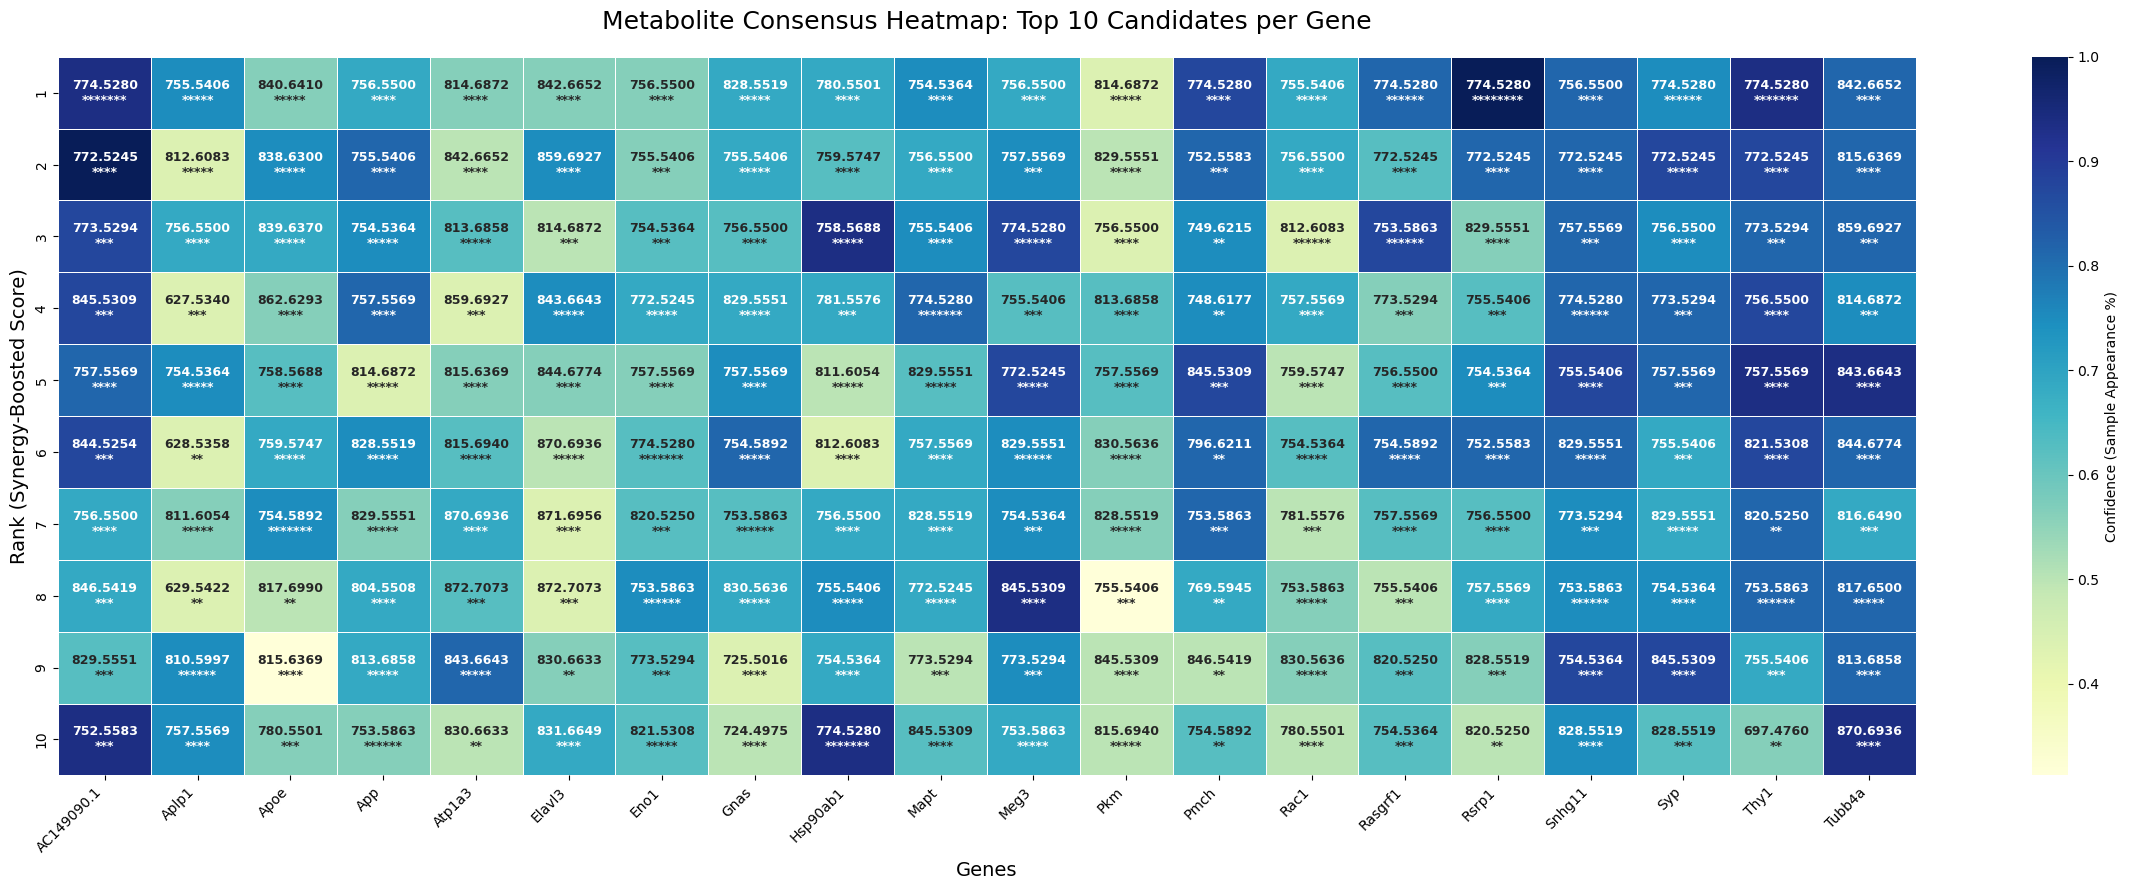

Analysis complete. Heatmap saved to gene_mz_consensus_heatmap.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top30_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv"
OUTPUT_HEATMAP = 'gene_mz_consensus_heatmap.png'

K_FACTOR = 1
SYNERGY_WEIGHT = 0.5 
TOLERANCE = 0.015  
TOP_N_RANKS = 10  # How many ranks to show per gene in the heatmap

RELATIONSHIPS = {
    'M+0': 0.0, 'M+1': 1.003355, 'M+2': 2.006710,
    'NH4': 17.02655, 'Na': 21.98204, 'K': 37.95548, 'H2O': -18.01056
}

# =============================================================================
# HELPERS & LOADERS
# =============================================================================
def load_validation_lookup(path):
    try:
        val_df = pd.read_csv(path)
        lookup = set()
        for _, row in val_df.iterrows():
            pair = frozenset([round(row['mz_1'], 4), round(row['mz_2'], 4)])
            lookup.add(pair)
        return lookup
    except: return set()

VALID_PAIRS = load_validation_lookup(VALIDATION_FILE)

def check_relationship(mz1, mz2):
    m1_r, m2_r = round(mz1, 4), round(mz2, 4)
    if frozenset([m1_r, m2_r]) in VALID_PAIRS: return "Validated"
    diff = abs(mz2 - mz1)
    for name1, shift1 in RELATIONSHIPS.items():
        for name2, shift2 in RELATIONSHIPS.items():
            if name1 == name2: continue
            if abs(diff - abs(shift2 - shift1)) < TOLERANCE:
                if any(x in [name1, name2] for x in ['M+1', 'M+2']): return None
                return f"Math_{name1}<->{name2}"
    return None

# =============================================================================
# MULTI-CANDIDATE PROCESSING
# =============================================================================
def get_all_ranked_candidates(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return []
    
    all_samples = subset['Sample'].unique()
    total_possible = len(all_samples)
    
    # Map raw data
    mz_data = {}
    for _, row in subset.iterrows():
        mz = row['MZ_Feature']
        if mz not in mz_data:
            mz_data[mz] = {'samples': set(), 'rrf': 0.0}
        mz_data[mz]['samples'].add(row['Sample'])
        mz_data[mz]['rrf'] += 1.0 / (row['Rank'] + K_FACTOR)

    candidates = list(mz_data.keys())
    final_list = []
    
    for focal_mz in candidates:
        consolidated_samples = mz_data[focal_mz]['samples'].copy()
        boosted_score = mz_data[focal_mz]['rrf']
        star_count = 0
        
        for other_mz in candidates:
            if focal_mz == other_mz: continue
            if check_relationship(focal_mz, other_mz):
                consolidated_samples.update(mz_data[other_mz]['samples'])
                common = mz_data[focal_mz]['samples'].intersection(mz_data[other_mz]['samples'])
                boosted_score += mz_data[other_mz]['rrf'] + (len(common) * SYNERGY_WEIGHT)
                star_count += 1
        
        final_list.append({
            'Gene': gene_name,
            'MZ': focal_mz,
            'Score': boosted_score,
            'Confidence': len(consolidated_samples) / total_possible,
            'Stars': star_count
        })
    
    # Sort by score and return with rank
    sorted_list = sorted(final_list, key=lambda x: x['Score'], reverse=True)
    for i, item in enumerate(sorted_list):
        item['Rank'] = i + 1
    return sorted_list

# =============================================================================
# MAIN EXECUTION & PLOTTING
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"Error: {INPUT_FILE} not found.")
    exit()

unique_genes = df['Gene'].unique()
all_results = []

for gene in unique_genes:
    gene_ranks = get_all_ranked_candidates(df, gene)
    all_results.extend(gene_ranks[:TOP_N_RANKS])

# Create Plotting DataFrame
h_df = pd.DataFrame(all_results)

# Pivot 1: Colors (Confidence Level)
conf_matrix = h_df.pivot(index='Rank', columns='Gene', values='Confidence')

# Pivot 2: Annotations (MZ + Stars)
def format_label(row):
    stars = "*" * int(row['Stars'])
    return f"{row['MZ']:.4f}\n{stars}"

h_df['Label'] = h_df.apply(format_label, axis=1)
label_matrix = h_df.pivot(index='Rank', columns='Gene', values='Label')

# Plotting
plt.figure(figsize=(max(14, len(unique_genes)*1.2), TOP_N_RANKS * 0.9))
sns.heatmap(conf_matrix, 
            annot=label_matrix, 
            fmt="", 
            cmap="YlGnBu", 
            cbar_kws={'label': 'Confidence (Sample Appearance %)'},
            linewidths=.5, 
            annot_kws={"size": 9, "weight": "bold"})

plt.title(f"Metabolite Consensus Heatmap: Top {TOP_N_RANKS} Candidates per Gene", fontsize=18, pad=20)
plt.xlabel("Genes", fontsize=14)
plt.ylabel("Rank (Synergy-Boosted Score)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#plt.savefig(OUTPUT_HEATMAP, dpi=300)
print(f"Analysis complete. Heatmap saved to {OUTPUT_HEATMAP}")

Successfully loaded 531 validated pairs from /home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv

GENE            | WINNER     | SAMPLES  | SCORE    | NOTES
------------------------------------------------------------------------------------------------------------------------
AC149090.1      | 774.5280   | 15/16 | 18.35    | Math_NH4<->Na, Math_Na<->K, Validated_Relationship, Math_M+0<->Na, Math_NH4<->K
Aplp1           | 755.5406   | 12/16 | 11.08    | Math_NH4<->Na, Validated_Relationship
Apoe            | 840.6410   | 9/16 | 13.19    | Math_NH4<->Na, Validated_Relationship
App             | 756.5500   | 11/16 | 11.77    | Math_Na<->K, Validated_Relationship
Atp1a3          | 814.6872   | 9/16 | 12.24    | Math_Na<->K, Math_M+0<->NH4, Validated_Relationship
Elavl3          | 842.6652   | 9/16 | 13.98    | Math_M+0<->Na, Validated_Relationship
Eno1            | 756.5500   | 9/16 | 12.78    | Math_Na<->K, Validated_Relationship


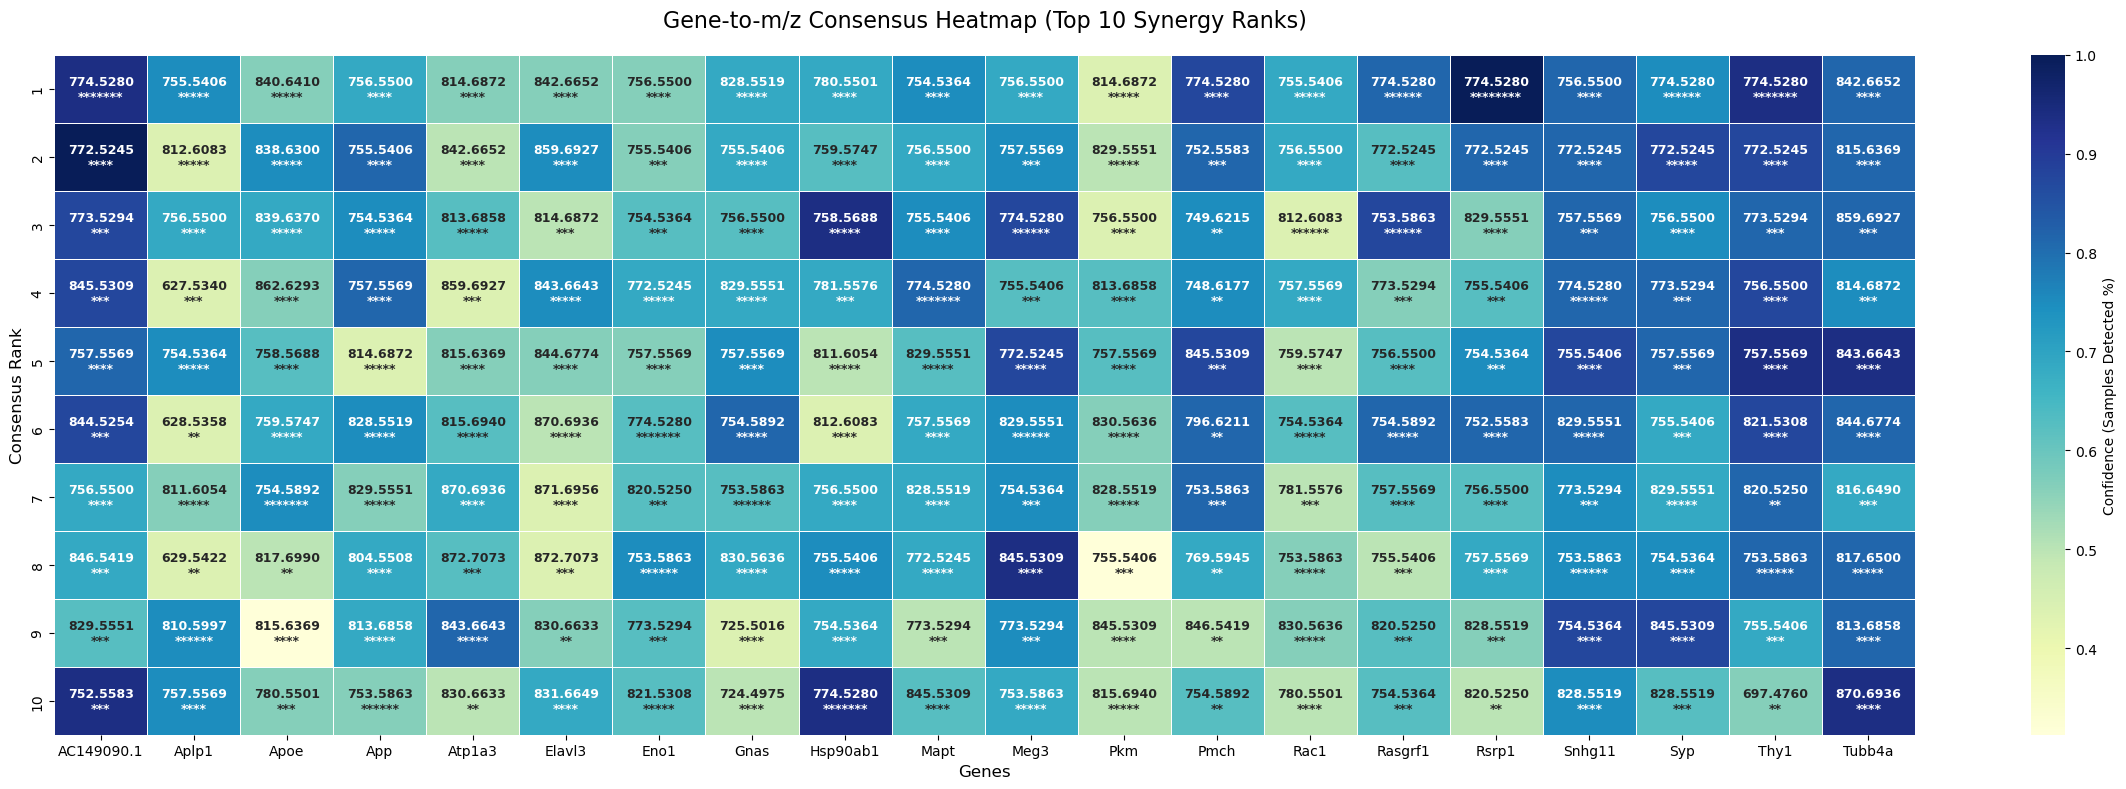

Heatmap visualization saved to 30_gene_to_mz_synced_results_v1_analytic_fast/gene_mz_consensus_heatmap.png


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top30_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv"
OUTPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/final_gene_to_mz_top30_matches_all_scores.csv'
OUTPUT_HEATMAP = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_mz_consensus_heatmap.png'

# RRF and Synergy Constants
K_FACTOR = 1
SYNERGY_WEIGHT = 0.5  # Bonus for each sample where two related peaks appear together
TOLERANCE = 0.015  
GROUPS = ['AAD', 'YC', 'AC', 'YAD'] 
TOP_N_RANKS_HEATMAP = 10  # Number of ranks to display in the heatmap

# Theoretical Mass shifts relative to the Neutral Parent (M)
RELATIONSHIPS = {
    'M+0': 0.0,
    'M+1': 1.003355,
    'M+2': 2.006710,
    'NH4': 17.02655,
    'Na':  21.98204,
    'K':   37.95548,
    'H2O': -18.01056
}

# =============================================================================
# DATA LOADING & VALIDATION LOOKUP
# =============================================================================
def load_validation_lookup(path):
    try:
        val_df = pd.read_csv(path)
        lookup = set()
        for _, row in val_df.iterrows():
            pair = frozenset([round(row['mz_1'], 4), round(row['mz_2'], 4)])
            lookup.add(pair)
        print(f"Successfully loaded {len(lookup)} validated pairs from {path}")
        return lookup
    except Exception as e:
        print(f"Error loading validation file: {e}")
        return set()

VALID_PAIRS = load_validation_lookup(VALIDATION_FILE)

# =============================================================================
# RELATIONSHIP ENGINE
# =============================================================================
def check_relationship(mz1, mz2):
    m1_r = round(mz1, 4)
    m2_r = round(mz2, 4)
    current_pair = frozenset([m1_r, m2_r])

    if current_pair in VALID_PAIRS:
        return "Validated_Relationship"

    diff = abs(mz2 - mz1)
    for name1, shift1 in RELATIONSHIPS.items():
        for name2, shift2 in RELATIONSHIPS.items():
            if name1 == name2: continue
            theoretical_diff = abs(shift2 - shift1)
            if abs(diff - theoretical_diff) < TOLERANCE:
                is_isotope_rel = any(x in [name1, name2] for x in ['M+1', 'M+2'])
                if is_isotope_rel:
                    return None 
                return f"Math_{name1}<->{name2}"
    return None

def identify_group(sample_name):
    for g in GROUPS:
        if g in sample_name: return g
    return "Other"

# =============================================================================
# CONSENSUS ALGORITHM
# =============================================================================
def calculate_consensus_all(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return []
    
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    total_counts_per_group = {g: 0 for g in GROUPS + ['Other']}
    for s in all_samples:
        total_counts_per_group[identify_group(s)] += 1
    
    mz_data = {} 
    for _, row in subset.iterrows():
        mz = row['MZ_Feature']
        if mz not in mz_data:
            mz_data[mz] = {'samples': set(), 'group_samples': {g: set() for g in GROUPS + ['Other']}, 'rrf_score': 0.0}
        group = identify_group(row['Sample'])
        mz_data[mz]['samples'].add(row['Sample'])
        mz_data[mz]['group_samples'][group].add(row['Sample'])
        mz_data[mz]['rrf_score'] += 1.0 / (row['Rank'] + K_FACTOR)

    candidates = list(mz_data.keys())
    final_stats = []
    
    for focal_mz in candidates:
        consolidated_all = mz_data[focal_mz]['samples'].copy()
        consolidated_groups = {g: mz_data[focal_mz]['group_samples'][g].copy() for g in GROUPS + ['Other']}
        boosted_score = mz_data[focal_mz]['rrf_score']
        related_found = []
        star_count = 0
        
        for other_mz in candidates:
            if focal_mz == other_mz: continue
            rel_type = check_relationship(focal_mz, other_mz)
            if rel_type:
                consolidated_all.update(mz_data[other_mz]['samples'])
                for g in GROUPS + ['Other']:
                    consolidated_groups[g].update(mz_data[other_mz]['group_samples'][g])
                co_occurrence = mz_data[focal_mz]['samples'].intersection(mz_data[other_mz]['samples'])
                boosted_score += mz_data[other_mz]['rrf_score'] + (len(co_occurrence) * SYNERGY_WEIGHT)
                related_found.append(rel_type)
                star_count += 1

        group_counts = {g: len(consolidated_groups[g]) for g in GROUPS}
        group_display = " | ".join([f"{g}:{group_counts[g]}/{total_counts_per_group[g]}" for g in GROUPS])

        final_stats.append({
            'Gene': gene_name,
            'mz': focal_mz,
            'final_score': boosted_score,
            'total_count': len(consolidated_all),
            'total_possible': total_samples_overall,
            'confidence_pct': len(consolidated_all) / total_samples_overall,
            'group_counts': group_counts,
            'group_display': group_display,
            'stars': star_count,
            'notes': ", ".join(list(set(related_found)))
        })

    final_stats.sort(key=lambda x: x['final_score'], reverse=True)
    return final_stats

# =============================================================================
# MAIN EXECUTION
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"Error: Could not find '{INPUT_FILE}'.")
    exit()

unique_genes = df['Gene'].unique()
full_consensus_results = []
heatmap_data = []

print(f"\n{'GENE':<15} | {'WINNER':<10} | {'SAMPLES':<8} | {'SCORE':<8} | {'NOTES'}")
print("-" * 120)

for gene in unique_genes:
    ranked_candidates = calculate_consensus_all(df, gene)
    if not ranked_candidates: continue
    
    # Process Winner for CSV
    w = ranked_candidates[0]
    pct = w['confidence_pct'] * 100
    confidence_label = "LOW"
    if pct >= 50: confidence_label = "MEDIUM"
    if pct >= 75: confidence_label = "HIGH"
    if pct >= 90: confidence_label = "V.HIGH"
    
    print(f"{gene:<15} | {w['mz']:<10.4f} | {w['total_count']}/{w['total_possible']:<2} | {w['final_score']:<8.2f} | {w['notes']}")
    
    full_consensus_results.append({
        'Gene': gene, 'Consensus_MZ': w['mz'], 'Synergy_Score': round(w['final_score'], 3),
        'Total_Found': w['total_count'], 'Total_Possible': w['total_possible'],
        'Confidence': confidence_label, 'Evidence_Notes': w['notes'], 'Group_Breakdown': w['group_display'],
        **{f'Count_{g}': w['group_counts'][g] for g in GROUPS}
    })

    # Collect Top N for Heatmap
    for i, cand in enumerate(ranked_candidates[:TOP_N_RANKS_HEATMAP]):
        heatmap_data.append({
            'Gene': gene, 'Rank': i + 1, 'MZ': cand['mz'],
            'Confidence': cand['confidence_pct'], 'Stars': cand['stars']
        })

# Save CSV
pd.DataFrame(full_consensus_results).to_csv(OUTPUT_FILE, index=False)
print("-" * 120)
print(f"Analysis Complete. Results saved to {OUTPUT_FILE}")

# =============================================================================
# HEATMAP GENERATION
# =============================================================================
if heatmap_data:
    h_df = pd.DataFrame(heatmap_data)
    
    # Pivot for Heatmap: Genes as columns, Rank as index
    conf_matrix = h_df.pivot(index='Rank', columns='Gene', values='Confidence')
    
    # Matrix for labels: m/z value + stars
    def format_label(row):
        return f"{row['MZ']:.4f}\n{'*' * int(row['Stars'])}"
    h_df['Label'] = h_df.apply(format_label, axis=1)
    label_matrix = h_df.pivot(index='Rank', columns='Gene', values='Label')

    plt.figure(figsize=(max(12, len(unique_genes)*1.2), TOP_N_RANKS_HEATMAP * 0.8))
    sns.heatmap(conf_matrix, annot=label_matrix, fmt="", cmap="YlGnBu", 
                cbar_kws={'label': 'Confidence (Samples Detected %)'},
                linewidths=.5, annot_kws={"size": 9, "weight": "bold"})
    
    plt.title(f"Gene-to-m/z Consensus Heatmap (Top {TOP_N_RANKS_HEATMAP} Synergy Ranks)", fontsize=16, pad=20)
    plt.xlabel("Genes", fontsize=12)
    plt.ylabel("Consensus Rank", fontsize=12)
    plt.tight_layout()
    plt.show()
    #plt.savefig(OUTPUT_HEATMAP, dpi=300)
    print(f"Heatmap visualization saved to {OUTPUT_HEATMAP}")

Successfully loaded 531 validated pairs. Precision set to 4 decimals.


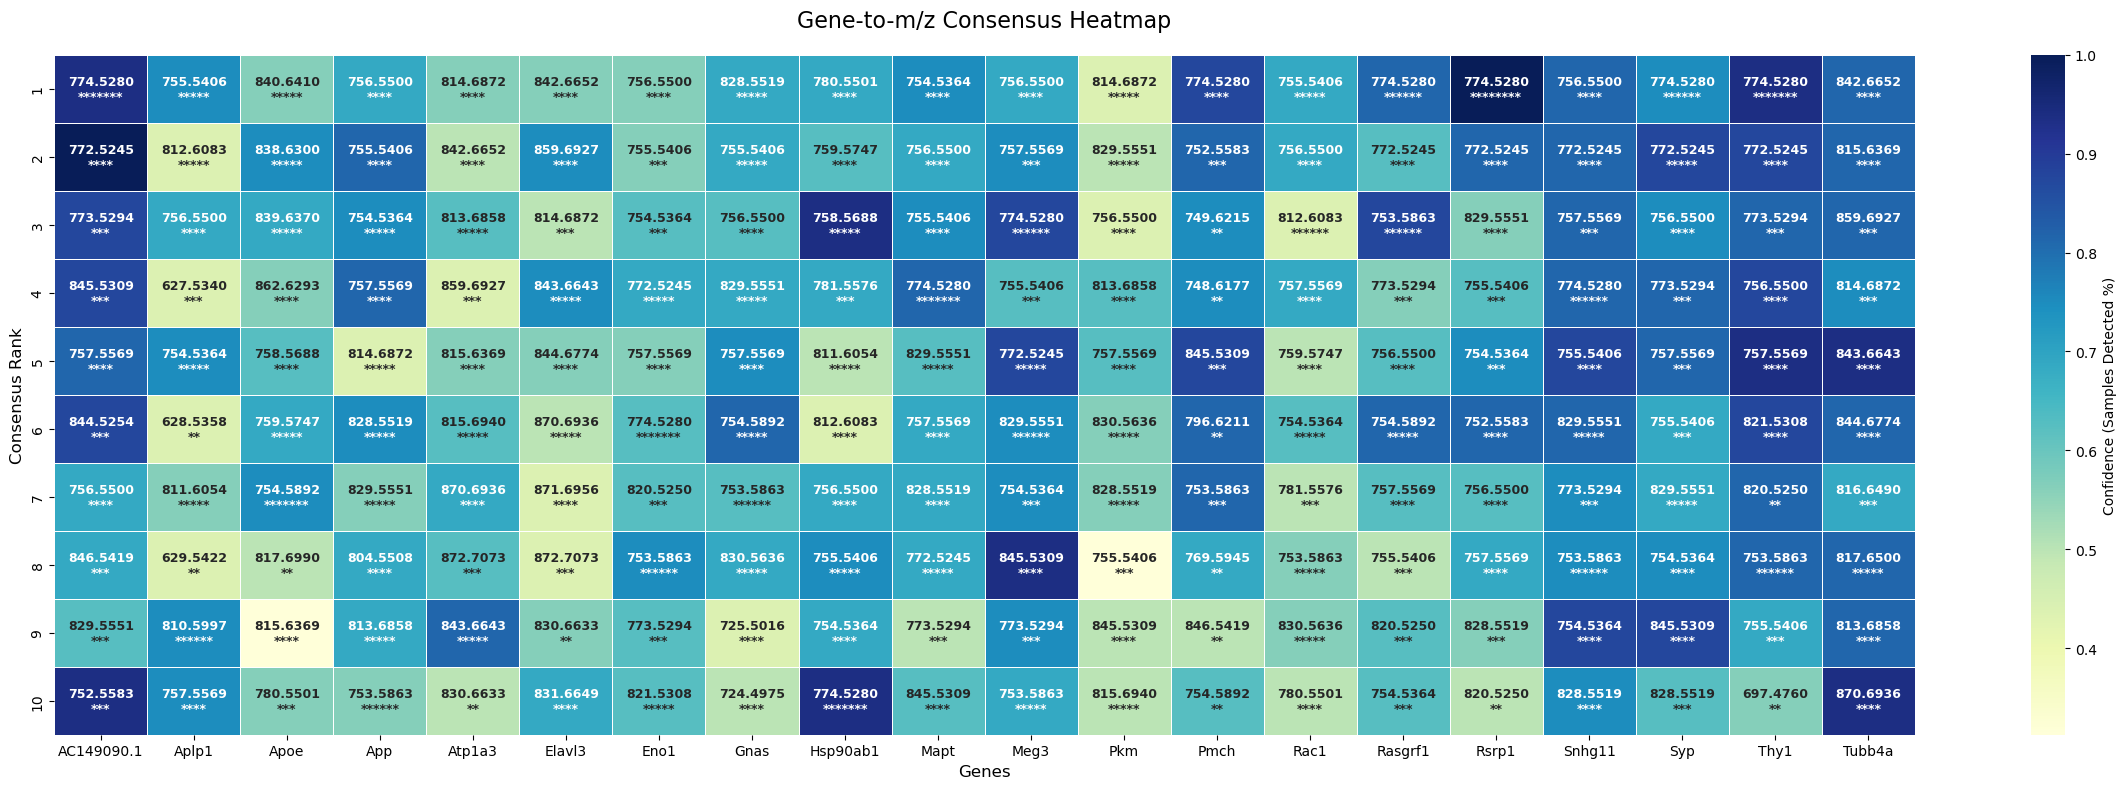

Complete. Heatmap saved to 30_gene_to_mz_synced_results_v1_analytic_fast/gene_mz_consensus_heatmap.png


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top30_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv"
OUTPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/final_gene_to_mz_top30_matches_all_scores.csv'
OUTPUT_HEATMAP = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_mz_consensus_heatmap.png'

K_FACTOR = 1
SYNERGY_WEIGHT = 0.5 
TOLERANCE = 0.015  
PRECISION = 4  # Number of decimals to round for matching (e.g., 865.5000 == 865.5)
GROUPS = ['AAD', 'YC', 'AC', 'YAD'] 
TOP_N_RANKS_HEATMAP = 10 

RELATIONSHIPS = {
    'M+0': 0.0, 'M+1': 1.003355, 'M+2': 2.006710,
    'NH4': 17.02655, 'Na': 21.98204, 'K': 37.95548, 'H2O': -18.01056
}

# =============================================================================
# DATA LOADING & VALIDATION LOOKUP
# =============================================================================
def load_validation_lookup(path):
    try:
        val_df = pd.read_csv(path)
        lookup = set()
        for _, row in val_df.iterrows():
            # Rounding here ensures 865.5000 becomes 865.5
            pair = frozenset([round(row['mz_1'], PRECISION), round(row['mz_2'], PRECISION)])
            lookup.add(pair)
        print(f"Successfully loaded {len(lookup)} validated pairs. Precision set to {PRECISION} decimals.")
        return lookup
    except Exception as e:
        print(f"Error loading validation file: {e}")
        return set()

VALID_PAIRS = load_validation_lookup(VALIDATION_FILE)

# =============================================================================
# RELATIONSHIP ENGINE
# =============================================================================
def check_relationship(mz1, mz2):
    # Rounding current candidates to match the lookup table precision
    m1_r = round(mz1, PRECISION)
    m2_r = round(mz2, PRECISION)
    current_pair = frozenset([m1_r, m2_r])

    # 1. Validation File Check (Primary)
    if current_pair in VALID_PAIRS:
        return "Validated_Relationship"

    # 2. Mathematical Check (Secondary)
    diff = abs(mz2 - mz1)
    for name1, shift1 in RELATIONSHIPS.items():
        for name2, shift2 in RELATIONSHIPS.items():
            if name1 == name2: continue
            theoretical_diff = abs(shift2 - shift1)
            if abs(diff - theoretical_diff) < TOLERANCE:
                # Isotopes MUST be validated via the CSV
                is_isotope_rel = any(x in [name1, name2] for x in ['M+1', 'M+2'])
                if is_isotope_rel:
                    return None 
                return f"Math_{name1}<->{name2}"
    return None

def identify_group(sample_name):
    for g in GROUPS:
        if g in sample_name: return g
    return "Other"

# =============================================================================
# CONSENSUS ALGORITHM
# =============================================================================
def calculate_consensus_all(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return []
    
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    total_counts_per_group = {g: 0 for g in GROUPS + ['Other']}
    for s in all_samples:
        total_counts_per_group[identify_group(s)] += 1
    
    mz_data = {} 
    for _, row in subset.iterrows():
        mz = row['MZ_Feature']
        if mz not in mz_data:
            mz_data[mz] = {'samples': set(), 'group_samples': {g: set() for g in GROUPS + ['Other']}, 'rrf_score': 0.0}
        group = identify_group(row['Sample'])
        mz_data[mz]['samples'].add(row['Sample'])
        mz_data[mz]['group_samples'][group].add(row['Sample'])
        mz_data[mz]['rrf_score'] += 1.0 / (row['Rank'] + K_FACTOR)

    candidates = list(mz_data.keys())
    final_stats = []
    
    for focal_mz in candidates:
        consolidated_all = mz_data[focal_mz]['samples'].copy()
        consolidated_groups = {g: mz_data[focal_mz]['group_samples'][g].copy() for g in GROUPS + ['Other']}
        boosted_score = mz_data[focal_mz]['rrf_score']
        related_found = []
        star_count = 0
        
        for other_mz in candidates:
            if focal_mz == other_mz: continue
            rel_type = check_relationship(focal_mz, other_mz)
            if rel_type:
                consolidated_all.update(mz_data[other_mz]['samples'])
                for g in GROUPS + ['Other']:
                    consolidated_groups[g].update(mz_data[other_mz]['group_samples'][g])
                co_occurrence = mz_data[focal_mz]['samples'].intersection(mz_data[other_mz]['samples'])
                boosted_score += mz_data[other_mz]['rrf_score'] + (len(co_occurrence) * SYNERGY_WEIGHT)
                related_found.append(rel_type)
                star_count += 1

        group_counts = {g: len(consolidated_groups[g]) for g in GROUPS}
        group_display = " | ".join([f"{g}:{group_counts[g]}/{total_counts_per_group[g]}" for g in GROUPS])

        final_stats.append({
            'Gene': gene_name, 'mz': focal_mz, 'final_score': boosted_score,
            'total_count': len(consolidated_all), 'total_possible': total_samples_overall,
            'confidence_pct': len(consolidated_all) / total_samples_overall,
            'group_counts': group_counts, 'group_display': group_display,
            'stars': star_count, 'notes': ", ".join(list(set(related_found)))
        })

    final_stats.sort(key=lambda x: x['final_score'], reverse=True)
    return final_stats

# =============================================================================
# MAIN EXECUTION
# =============================================================================
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"Error: Could not find '{INPUT_FILE}'.")
    exit()

unique_genes = df['Gene'].unique()
full_consensus_results = []
heatmap_data = []

for gene in unique_genes:
    ranked_candidates = calculate_consensus_all(df, gene)
    if not ranked_candidates: continue
    
    w = ranked_candidates[0]
    full_consensus_results.append({
        'Gene': gene, 'Consensus_MZ': w['mz'], 'Synergy_Score': round(w['final_score'], 3),
        'Total_Found': w['total_count'], 'Total_Possible': w['total_possible'],
        'Evidence_Notes': w['notes'], 'Group_Breakdown': w['group_display'],
        **{f'Count_{g}': w['group_counts'][g] for g in GROUPS}
    })

    for i, cand in enumerate(ranked_candidates[:TOP_N_RANKS_HEATMAP]):
        heatmap_data.append({
            'Gene': gene, 'Rank': i + 1, 'MZ': cand['mz'],
            'Confidence': cand['confidence_pct'], 'Stars': cand['stars']
        })

pd.DataFrame(full_consensus_results).to_csv(OUTPUT_FILE, index=False)

# =============================================================================
# HEATMAP GENERATION
# =============================================================================
if heatmap_data:
    h_df = pd.DataFrame(heatmap_data)
    conf_matrix = h_df.pivot(index='Rank', columns='Gene', values='Confidence')
    
    def format_label(row):
        return f"{row['MZ']:.4f}\n{'*' * int(row['Stars'])}"
    h_df['Label'] = h_df.apply(format_label, axis=1)
    label_matrix = h_df.pivot(index='Rank', columns='Gene', values='Label')

    plt.figure(figsize=(max(12, len(unique_genes)*1.2), TOP_N_RANKS_HEATMAP * 0.8))
    sns.heatmap(conf_matrix, annot=label_matrix, fmt="", cmap="YlGnBu", 
                cbar_kws={'label': 'Confidence (Samples Detected %)'},
                linewidths=.5, annot_kws={"size": 9, "weight": "bold"})
    
    plt.title(f"Gene-to-m/z Consensus Heatmap", fontsize=16, pad=20)
    plt.xlabel("Genes", fontsize=12)
    plt.ylabel("Consensus Rank", fontsize=12)
    plt.tight_layout()
    #plt.savefig(OUTPUT_HEATMAP, dpi=300)
    plt.show()
    print(f"Complete. Heatmap saved to {OUTPUT_HEATMAP}")

Loaded 531 validated pairs.


/tmp/ipykernel_416436/366162718.py:186: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  label_matrix = h_df.pivot(index='Rank', columns='Gene', values='MZ').applymap(lambda x: f"{x:.4f}")


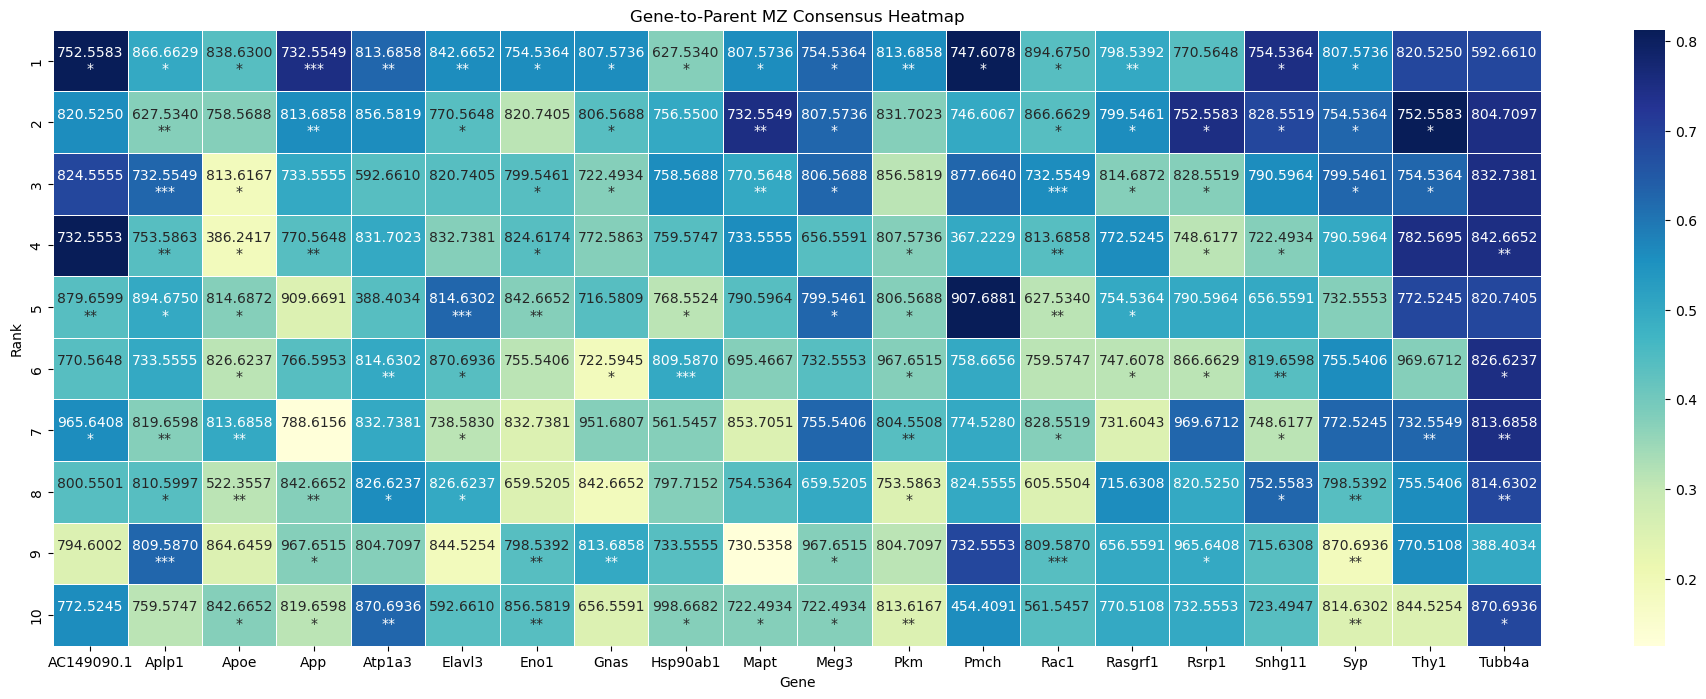

Done. Parent-centric heatmap generated.


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top30_matches_all_scores.csv' 
VALIDATION_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/identified_isotopes.csv"
OUTPUT_FILE = '30_gene_to_mz_synced_results_v1_analytic_fast/final_gene_to_mz_top30_matches_all_scores.csv'
OUTPUT_HEATMAP = '30_gene_to_mz_synced_results_v1_analytic_fast/gene_mz_consensus_heatmap.png'

K_FACTOR = 1
SYNERGY_WEIGHT = 0.5 
TOLERANCE = 0.015  
PRECISION = 4  
GROUPS = ['AAD', 'YC', 'AC', 'YAD'] 
TOP_N_RANKS_HEATMAP = 10 

# Theoretical Mass shifts relative to the Neutral Parent (M)
RELATIONSHIPS = {
    'M+0': 0.0,
    'M+1': 1.003355,
    'M+2': 2.006710,
    'NH4': 17.02655,
    'Na':  21.98204,
    'K':   37.95548,
    'H2O': -18.01056
}

# =============================================================================
# DATA LOADING & VALIDATION LOOKUP
# =============================================================================
def load_validation_lookup(path):
    try:
        val_df = pd.read_csv(path)
        lookup = set()
        for _, row in val_df.iterrows():
            pair = frozenset([round(row['mz_1'], PRECISION), round(row['mz_2'], PRECISION)])
            lookup.add(pair)
        print(f"Loaded {len(lookup)} validated pairs.")
        return lookup
    except Exception as e:
        print(f"Error loading validation file: {e}")
        return set()

VALID_PAIRS = load_validation_lookup(VALIDATION_FILE)

# =============================================================================
# RELATIONSHIP ENGINE
# =============================================================================
def get_theoretical_parent(mz, relationship_name):
    """Calculates what the M+0 mass would be given a specific child type."""
    return mz - RELATIONSHIPS[relationship_name]

def check_relationship(mz1, mz2):
    m1_r, m2_r = round(mz1, PRECISION), round(mz2, PRECISION)
    if frozenset([m1_r, m2_r]) in VALID_PAIRS:
        return "Validated_Relationship"

    diff = abs(mz2 - mz1)
    for name1, shift1 in RELATIONSHIPS.items():
        for name2, shift2 in RELATIONSHIPS.items():
            if name1 == name2: continue
            if abs(diff - abs(shift2 - shift1)) < TOLERANCE:
                if any(x in [name1, name2] for x in ['M+1', 'M+2']): return None 
                return f"Math_{name1}<->{name2}"
    return None

# =============================================================================
# CONSENSUS ALGORITHM WITH VIRTUAL PARENT LOGIC
# =============================================================================
def calculate_consensus_all(df, gene_name):
    subset = df[df['Gene'] == gene_name]
    if subset.empty: return []
    
    all_samples = subset['Sample'].unique()
    total_samples_overall = len(all_samples)
    
    # 1. Identify all unique MZs and their potential parents
    raw_mz_data = {}
    for _, row in subset.iterrows():
        mz = row['MZ_Feature']
        # For every peak, check if it COULD be a child. 
        # If it is, we find its "Theoretical Parent"
        parent_mass = mz # Default
        best_rel = "M+0"
        
        for rel_name, shift in RELATIONSHIPS.items():
            potential_p = mz - shift
            # Check if this potential parent or its family exists in VALID_PAIRS
            # This is a 'soft' check to see if we should re-assign to parent
            for other_mz in subset['MZ_Feature'].unique():
                if abs(other_mz - potential_p) < TOLERANCE:
                    parent_mass = other_mz
                    best_rel = rel_name
                    break
        
        # Override: If it's clearly a child (like M+1) but the parent is missing, 
        # we "force" the parent mass to be the reference.
        if parent_mass == mz and best_rel == "M+0":
            for rel_name in ['M+1', 'M+2', 'Na', 'NH4', 'K']:
                # If mass is high enough to be that child...
                if mz > RELATIONSHIPS[rel_name]:
                    # We flag it as a Virtual Parent
                    parent_mass = mz - RELATIONSHIPS[rel_name]
                    best_rel = rel_name
                    # Note: We only do this if it helps group things, 
                    # but for this request, we prioritize the parent mass.

        if parent_mass not in raw_mz_data:
            raw_mz_data[parent_mass] = {'samples': set(), 'rrf_score': 0.0, 'original_mzs': set()}
        
        raw_mz_data[parent_mass]['samples'].add(row['Sample'])
        raw_mz_data[parent_mass]['rrf_score'] += 1.0 / (row['Rank'] + K_FACTOR)
        raw_mz_data[parent_mass]['original_mzs'].add(mz)

    # 2. Family Analysis & Synergy
    candidates = list(raw_mz_data.keys())
    final_stats = []
    
    for focal_p in candidates:
        consolidated_all = raw_mz_data[focal_p]['samples'].copy()
        boosted_score = raw_mz_data[focal_p]['rrf_score']
        star_count = len(raw_mz_data[focal_p]['original_mzs']) - 1
        
        for other_p in candidates:
            if focal_p == other_p: continue
            # Check if two theoretical parents are actually the same
            if abs(focal_p - other_p) < TOLERANCE:
                consolidated_all.update(raw_mz_data[other_p]['samples'])
                boosted_score += raw_mz_data[other_p]['rrf_score']
                star_count += len(raw_mz_data[other_p]['original_mzs'])

        final_stats.append({
            'Gene': gene_name, 'mz': focal_p, 'final_score': boosted_score,
            'total_count': len(consolidated_all), 'total_possible': total_samples_overall,
            'confidence_pct': len(consolidated_all) / total_samples_overall,
            'stars': star_count
        })

    final_stats.sort(key=lambda x: x['final_score'], reverse=True)
    return final_stats

# =============================================================================
# MAIN EXECUTION & HEATMAP
# =============================================================================
# [Data loading logic as before...]
try:
    df = pd.read_csv(INPUT_FILE)
    df.columns = [c.title() for c in df.columns]
    if 'Rna_Sample' in df.columns: df.rename(columns={'Rna_Sample': 'Sample'}, inplace=True)
    if 'Mz_Feature' in df.columns: df.rename(columns={'Mz_Feature': 'MZ_Feature'}, inplace=True)
except FileNotFoundError:
    print(f"Error: Could not find '{INPUT_FILE}'.")
    exit()

unique_genes = df['Gene'].unique()
full_results = []
heatmap_data = []

for gene in unique_genes:
    ranked = calculate_consensus_all(df, gene)
    if not ranked: continue
    
    w = ranked[0]
    full_results.append({
        'Gene': gene, 'Parent_MZ': round(w['mz'], 4), 'Score': round(w['final_score'], 3),
        'Samples': f"{w['total_count']}/{w['total_possible']}", 'Stars': w['stars']
    })

    for i, cand in enumerate(ranked[:TOP_N_RANKS_HEATMAP]):
        heatmap_data.append({
            'Gene': gene, 'Rank': i + 1, 'MZ': cand['mz'],
            'Confidence': cand['confidence_pct'], 'Stars': cand['stars']
        })

# Save and Plot
pd.DataFrame(full_results).to_csv(OUTPUT_FILE, index=False)

if heatmap_data:
    h_df = pd.DataFrame(heatmap_data)
    conf_matrix = h_df.pivot(index='Rank', columns='Gene', values='Confidence')
    label_matrix = h_df.pivot(index='Rank', columns='Gene', values='MZ').applymap(lambda x: f"{x:.4f}")
    # Add stars to labels
    for r in range(1, TOP_N_RANKS_HEATMAP + 1):
        for g in unique_genes:
            mask = (h_df['Rank'] == r) & (h_df['Gene'] == g)
            if mask.any():
                stars = "*" * int(h_df.loc[mask, 'Stars'].values[0])
                label_matrix.loc[r, g] += f"\n{stars}"

    plt.figure(figsize=(max(12, len(unique_genes)*1.2), TOP_N_RANKS_HEATMAP * 0.8))
    sns.heatmap(conf_matrix, annot=label_matrix, fmt="", cmap="YlGnBu", linewidths=.5)
    plt.title("Gene-to-Parent MZ Consensus Heatmap")
    #plt.savefig(OUTPUT_HEATMAP, dpi=300)
    plt.show()
    print("Done. Parent-centric heatmap generated.")